In [1]:
import ast
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and prepare submissions (same logic as fit_bkt.py)
df_raw = pd.read_csv('data/submissions.csv', low_memory=False)
df = df_raw[df_raw['eventType'] == 'answerStep'].copy()
df = df[df['knowledgeComponents'].notna()]
df['knowledgeComponents'] = df['knowledgeComponents'].apply(ast.literal_eval)
df = df.explode('knowledgeComponents')
df = df.rename(columns={
    'oats_user_id': 'user_id',
    'knowledgeComponents': 'skill_name',
    'time_stamp': 'order_id',
    'isCorrect': 'correct',
})
df['correct'] = df['correct'].astype(int)
df = df[['user_id', 'skill_name', 'order_id', 'correct', 'semester']].dropna(subset=['user_id', 'skill_name', 'order_id', 'correct'])
df = df.sort_values(['user_id', 'order_id'])

# Load fitted params
params = pd.read_csv('data/fitted_params.csv', index_col=[0,1,2])
flat = params['value'].unstack('param').droplevel('class')

# Load JSON to see which KCs were updated
with open('../../OATutor-Content/bkt-params/experimentalBKTParams.json') as f:
    bkt_json = json.load(f)

updated_kcs = [kc for kc in flat.index if kc in bkt_json]
print(f'Total answerStep rows: {len(df):,}')
print(f'Fitted KCs: {len(flat)}')
print(f'Updated in JSON: {len(updated_kcs)}')

Total answerStep rows: 189,966
Fitted KCs: 284
Updated in JSON: 97


In [2]:
# Summary table of all updated KCs with fitted params and flags
rows = []
for kc in updated_kcs:
    row = flat.loc[kc]
    sub = df[df['skill_name'] == kc]
    n_students = sub['user_id'].nunique()
    n_responses = len(sub)
    correct_rate = sub['correct'].mean()
    flags = []
    if row['slips'] > 0.3:    flags.append('high_slip')
    if row['guesses'] > 0.3:  flags.append('high_guess')
    if row['learns'] > 0.9:   flags.append('high_transit')
    if row['learns'] < 0.02:  flags.append('low_transit')
    if row['prior'] > 0.8:    flags.append('high_prior')
    rows.append({
        'kc': kc,
        'n_students': n_students,
        'n_responses': n_responses,
        'correct_rate': round(correct_rate, 3),
        'probMastery':  round(row['prior'], 4),
        'probTransit':  round(row['learns'], 4),
        'probSlip':     round(row['slips'], 4),
        'probGuess':    round(row['guesses'], 4),
        'flags': ' '.join(flags),
    })

summary = pd.DataFrame(rows).set_index('kc').sort_values('flags')
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 60)
summary

,n_students,n_responses,correct_rate,probMastery,probTransit,probSlip,probGuess,flags
kc,,,,,,,,
multiplying_polynomials,25,104,0.577,0.2093,0.1586,0.0887,0.2807,
modeling_with_linear_functions,18,112,0.696,0.3333,0.2000,0.0004,0.2738,
finding_the_quotient_of_a_product,27,142,0.817,0.7096,0.6645,0.1098,0.0075,
multiplying_complex_numbers,24,215,0.726,0.7375,0.5094,0.2365,0.0024,
finding_reference_angle,16,131,0.687,0.5936,0.8655,0.2719,0.0113,
finding_function_values_for_the_sine_and_cosine,16,110,0.727,0.7311,0.2432,0.1962,0.2900,
rates_of_change_and_behavior_of_graphs,25,227,0.683,0.4605,0.2419,0.1104,0.0000,
recognize_and_use_the_appropriate_method_to_factor_a_polynomial_completely,16,148,0.676,0.4375,0.0836,0.1302,0.2918,
evaluating_functions_expressed_in_formulas,35,362,0.525,0.3430,0.1185,0.1987,0.1803,


In [3]:
# Inspect a single KC — change this to any KC you want to investigate
KC = 'using_the_horizontal_line_test'

sub = df[df['skill_name'] == KC].copy()
print(f'KC: {KC}')
print(f'Students: {sub["user_id"].nunique()}')
print(f'Responses: {len(sub)}')
print(f'Overall correct rate: {sub["correct"].mean():.1%}')
print()
print('Fitted params:')
if KC in flat.index:
    print(flat.loc[KC][['prior','learns','slips','guesses']].to_string())
print()

# Response sequences per student (attempt 1, 2, 3, ...)
sequences = sub.groupby('user_id')['correct'].apply(list)
seq_lengths = sequences.apply(len)
print('Sequence length distribution:')
print(seq_lengths.value_counts().sort_index().to_string())

KC: using_the_horizontal_line_test
Students: 34
Responses: 182
Overall correct rate: 80.8%

Fitted params:
param
prior      0.288258
learns     0.966800
slips      0.222968
guesses    1.000000

Sequence length distribution:
correct
2      2
3     17
4      1
5      1
6      5
7      1
8      2
9      1
10     1
11     1
17     1
18     1


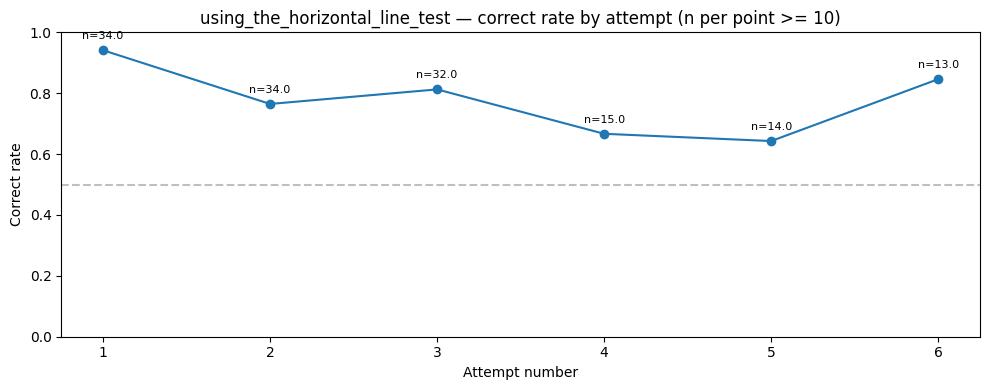

In [4]:
# Plot correct rate by attempt number for the selected KC
sub = df[df['skill_name'] == KC].copy()
sub['attempt'] = sub.groupby('user_id').cumcount() + 1

attempt_stats = sub.groupby('attempt').agg(
    correct_rate=('correct', 'mean'),
    n=('correct', 'count')
).reset_index()
# Only show attempts with enough students
attempt_stats = attempt_stats[attempt_stats['n'] >= 10]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(attempt_stats['attempt'], attempt_stats['correct_rate'], marker='o')
ax.set_xlabel('Attempt number')
ax.set_ylabel('Correct rate')
ax.set_title(f'{KC} — correct rate by attempt (n per point >= 10)')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)

# Annotate with n
for _, r in attempt_stats.iterrows():
    ax.annotate(f'n={r["n"]}', (r['attempt'], r['correct_rate']), 
                textcoords='offset points', xytext=(0, 8), fontsize=8, ha='center')
plt.tight_layout()
plt.show()

In [5]:
# Show first 20 student sequences for the selected KC
# 1 = correct, 0 = incorrect
sub = df[df['skill_name'] == KC]
sequences = sub.groupby('user_id')['correct'].apply(list)
for uid, seq in list(sequences.items())[:20]:
    bar = ''.join(['█' if c else '░' for c in seq])
    print(f'{str(uid)[:12]:12s}  {bar}  ({len(seq)} attempts, {sum(seq)}/{len(seq)} correct)')

55927658      ███  (3 attempts, 3/3 correct)
146176322     ███  (3 attempts, 3/3 correct)
181989919     ███  (3 attempts, 3/3 correct)
229882301     ███  (3 attempts, 3/3 correct)
708692619     ███  (3 attempts, 3/3 correct)
830235012     ███  (3 attempts, 3/3 correct)
952181648     ███  (3 attempts, 3/3 correct)
1003321460    ██  (2 attempts, 2/2 correct)
1017806644    █████░████  (10 attempts, 9/10 correct)
1176699175    ███  (3 attempts, 3/3 correct)
1418403855    ██░███  (6 attempts, 5/6 correct)
1419175221    ░██░░░█░██░███████  (18 attempts, 12/18 correct)
1816030333    ███  (3 attempts, 3/3 correct)
1871602612    ███  (3 attempts, 3/3 correct)
2036301597    █░██░███  (8 attempts, 6/8 correct)
2333892141    █░█  (3 attempts, 2/3 correct)
2581048581    █░████  (6 attempts, 5/6 correct)
2603602298    █░████  (6 attempts, 5/6 correct)
2898067363    ░█░██  (5 attempts, 3/5 correct)
2968447253    █░████  (6 attempts, 5/6 correct)


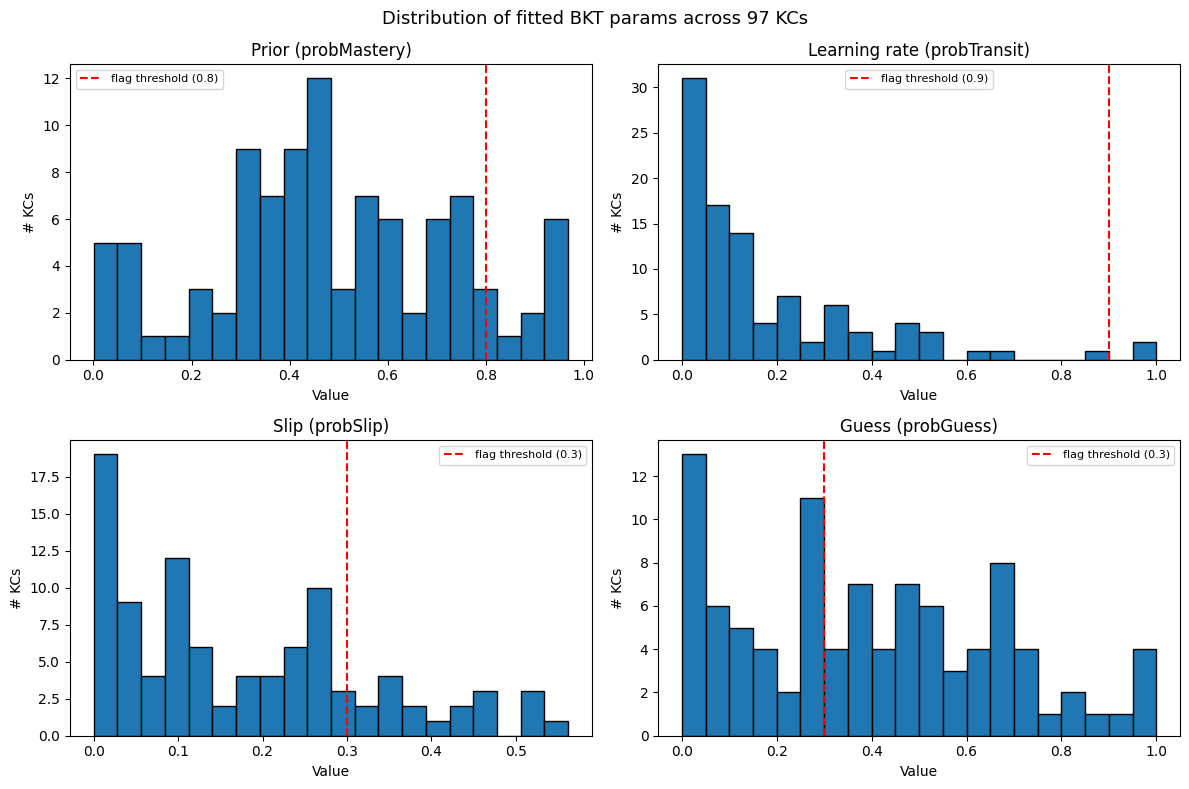

In [6]:
# Compare params across all updated KCs visually
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
param_cols = ['probMastery', 'probTransit', 'probSlip', 'probGuess']
titles = ['Prior (probMastery)', 'Learning rate (probTransit)', 'Slip (probSlip)', 'Guess (probGuess)']
thresholds = [0.8, 0.9, 0.3, 0.3]

for ax, col, title, thresh in zip(axes.flat, param_cols, titles, thresholds):
    ax.hist(summary[col], bins=20, edgecolor='black')
    ax.axvline(thresh, color='red', linestyle='--', label=f'flag threshold ({thresh})')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('# KCs')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of fitted BKT params across 97 KCs', fontsize=13)
plt.tight_layout()
plt.show()

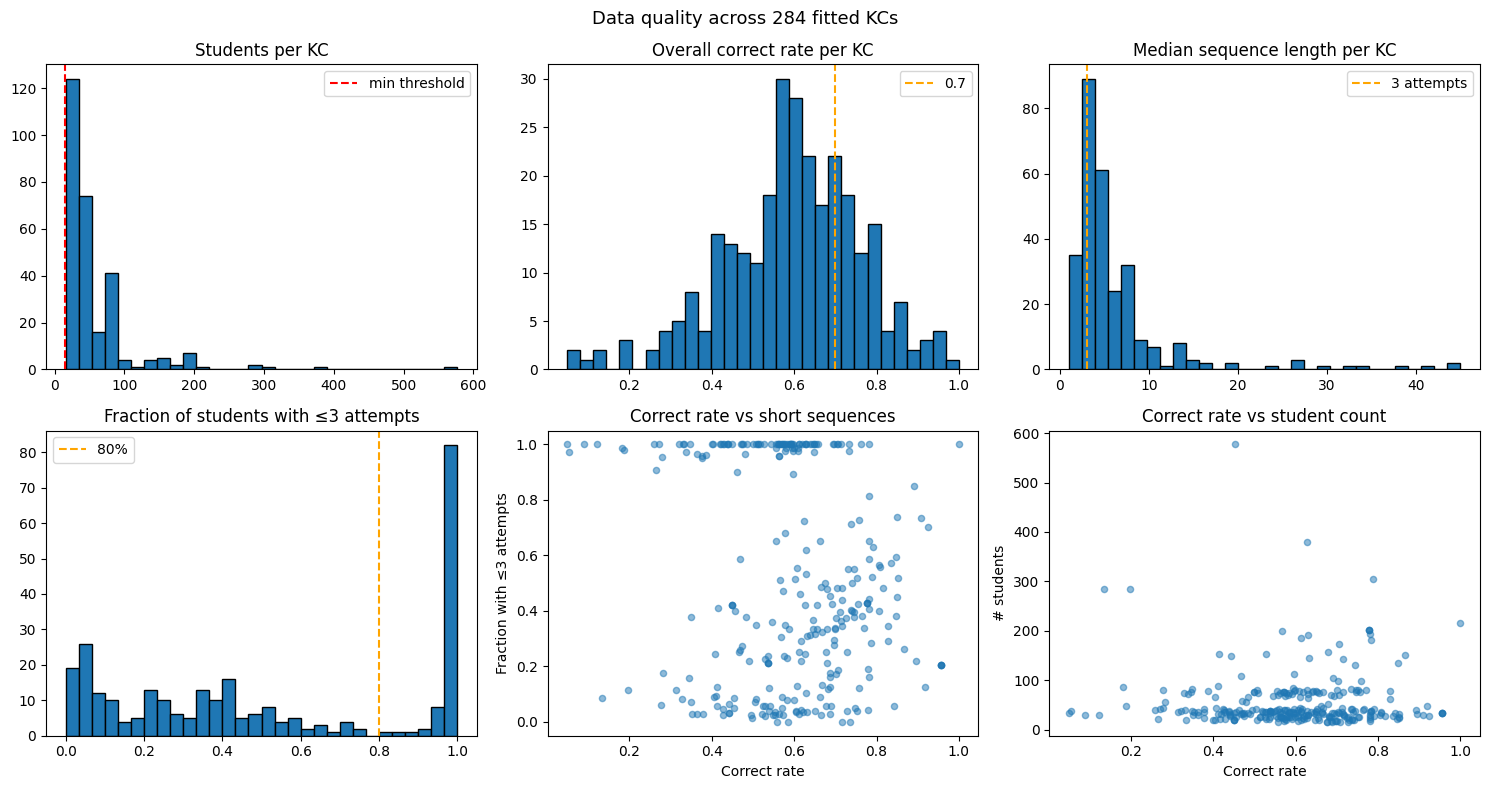

Median correct rate across all KCs: 60.3%
KCs with correct rate > 70%: 75
KCs where >80% of students have ≤3 attempts: 95
KCs with both (high correct rate AND short sequences): 10


In [7]:
# Data quality overview across all 284 fitted KCs
fitted_kcs = flat.index.tolist()

rows = []
for kc in fitted_kcs:
    sub = df[df['skill_name'] == kc]
    seqs = sub.groupby('user_id')['correct'].apply(list)
    seq_lengths = seqs.apply(len)
    rows.append({
        'kc': kc,
        'n_students': sub['user_id'].nunique(),
        'n_responses': len(sub),
        'correct_rate': sub['correct'].mean(),
        'median_seq_len': seq_lengths.median(),
        'pct_seq_lte3': (seq_lengths <= 3).mean(),
    })

quality = pd.DataFrame(rows).set_index('kc')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].hist(quality['n_students'], bins=30, edgecolor='black')
axes[0,0].set_title('Students per KC')
axes[0,0].axvline(15, color='red', linestyle='--', label='min threshold')
axes[0,0].legend()

axes[0,1].hist(quality['correct_rate'], bins=30, edgecolor='black')
axes[0,1].set_title('Overall correct rate per KC')
axes[0,1].axvline(0.7, color='orange', linestyle='--', label='0.7')
axes[0,1].legend()

axes[0,2].hist(quality['median_seq_len'], bins=30, edgecolor='black')
axes[0,2].set_title('Median sequence length per KC')
axes[0,2].axvline(3, color='orange', linestyle='--', label='3 attempts')
axes[0,2].legend()

axes[1,0].hist(quality['pct_seq_lte3'], bins=30, edgecolor='black')
axes[1,0].set_title('Fraction of students with ≤3 attempts')
axes[1,0].axvline(0.8, color='orange', linestyle='--', label='80%')
axes[1,0].legend()

axes[1,1].scatter(quality['correct_rate'], quality['pct_seq_lte3'], alpha=0.5, s=20)
axes[1,1].set_xlabel('Correct rate')
axes[1,1].set_ylabel('Fraction with ≤3 attempts')
axes[1,1].set_title('Correct rate vs short sequences')

axes[1,2].scatter(quality['correct_rate'], quality['n_students'], alpha=0.5, s=20)
axes[1,2].set_xlabel('Correct rate')
axes[1,2].set_ylabel('# students')
axes[1,2].set_title('Correct rate vs student count')

plt.suptitle('Data quality across 284 fitted KCs', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Median correct rate across all KCs: {quality['correct_rate'].median():.1%}")
print(f"KCs with correct rate > 70%: {(quality['correct_rate'] > 0.7).sum()}")
print(f"KCs where >80% of students have ≤3 attempts: {(quality['pct_seq_lte3'] > 0.8).sum()}")
print(f"KCs with both (high correct rate AND short sequences): {((quality['correct_rate'] > 0.7) & (quality['pct_seq_lte3'] > 0.8)).sum()}")

In [8]:
# ── Unflagged KCs: impact, courses, and sequence analysis ──────────────────

unflagged = []
for kc in flat.index:
    if kc not in bkt_json:
        continue
    row = flat.loc[kc]
    if not (row['slips'] > 0.3 or row['guesses'] > 0.3 or
            row['learns'] > 0.9 or row['learns'] < 0.02 or row['prior'] > 0.8):
        unflagged.append(kc)

print(f'Unflagged KCs: {len(unflagged)}\n')

rows = []
for kc in unflagged:
    sub = df_raw[df_raw['eventType'] == 'answerStep'].copy()
    sub = sub[sub['knowledgeComponents'].notna()]
    sub['knowledgeComponents'] = sub['knowledgeComponents'].apply(ast.literal_eval)
    sub = sub.explode('knowledgeComponents')
    sub = sub[sub['knowledgeComponents'] == kc].copy()
    sub = sub.rename(columns={'oats_user_id': 'user_id', 'isCorrect': 'correct'})
    sub['correct'] = sub['correct'].astype(int)
    sub = sub.sort_values('time_stamp')

    seqs = sub.groupby('user_id')['correct'].apply(list)
    seq_lengths = seqs.apply(len)
    courses = sorted(sub['course_name'].dropna().unique())

    rows.append({
        'kc': kc,
        'responses': len(sub),
        'students': sub['user_id'].nunique(),
        'correct_rate': round(sub['correct'].mean(), 3),
        'median_seq_len': seq_lengths.median(),
        'pct_lte3': round((seq_lengths <= 3).mean(), 2),
        'probMastery': round(flat.loc[kc, 'prior'], 4),
        'probTransit': round(flat.loc[kc, 'learns'], 4),
        'probSlip':    round(flat.loc[kc, 'slips'], 4),
        'probGuess':   round(flat.loc[kc, 'guesses'], 4),
        'courses': ', '.join(c.split(' ')[0] for c in courses) if courses else 'unknown',
    })

unflagged_df = pd.DataFrame(rows).set_index('kc').sort_values('responses', ascending=False)
pd.set_option('display.max_colwidth', 80)
unflagged_df

Unflagged KCs: 19



,responses,students,correct_rate,median_seq_len,pct_lte3,probMastery,probTransit,probSlip,probGuess,courses
kc,,,,,,,,,,
using_scientific_notation,1223,108,0.468,6.0,0.26,0.5690,0.0291,0.2549,0.1757,"AIED, MAT-001-31365, MAT-001-71668, MAT-001-72135, MAT-001-72192, SP26:, SP2..."
evaluating_functions_expressed_in_formulas,362,35,0.525,9.0,0.06,0.3430,0.1185,0.1987,0.1803,"MAT-003-31749, MAT-003-78818, MAT-003-78819"
using_the_midpoint_formula,286,32,0.490,7.5,0.22,0.4689,0.0985,0.1337,0.0747,"MAT-001-71668, MAT-001-72135"
rates_of_change_and_behavior_of_graphs,227,25,0.683,7.0,0.12,0.4605,0.2419,0.1104,0.0000,"MAT-003-31749, MAT-003-78818, MAT-003-78819"
using_function_notation,218,33,0.693,5.0,0.42,0.7141,0.6308,0.2665,0.0620,"MAT-003-31749, MAT-003-78818, MAT-003-78819"
multiplying_complex_numbers,215,24,0.726,5.5,0.38,0.7375,0.5094,0.2365,0.0024,"MAT-001-71668, MAT-001-72135, MAT-001-72192"
solve_equations_using_the_subtraction_and_addition_properties_of_equality,210,25,0.681,4.0,0.48,0.3211,0.2314,0.1511,0.0966,"FA25:, FA25:, SP26:, SP26:, SP26:, SP26:"
evaluate_variable_expressions_with_fractions,208,33,0.601,3.0,0.52,0.3522,0.1239,0.0300,0.2940,"SP26:, SP26:, SP26:, SP26:, SP26:"
solving_linear_equations_in_one_variable,189,31,0.667,5.0,0.32,0.3435,0.3275,0.1608,0.2619,"MAT-001-71668, MAT-001-72135, MAT-001-72192"


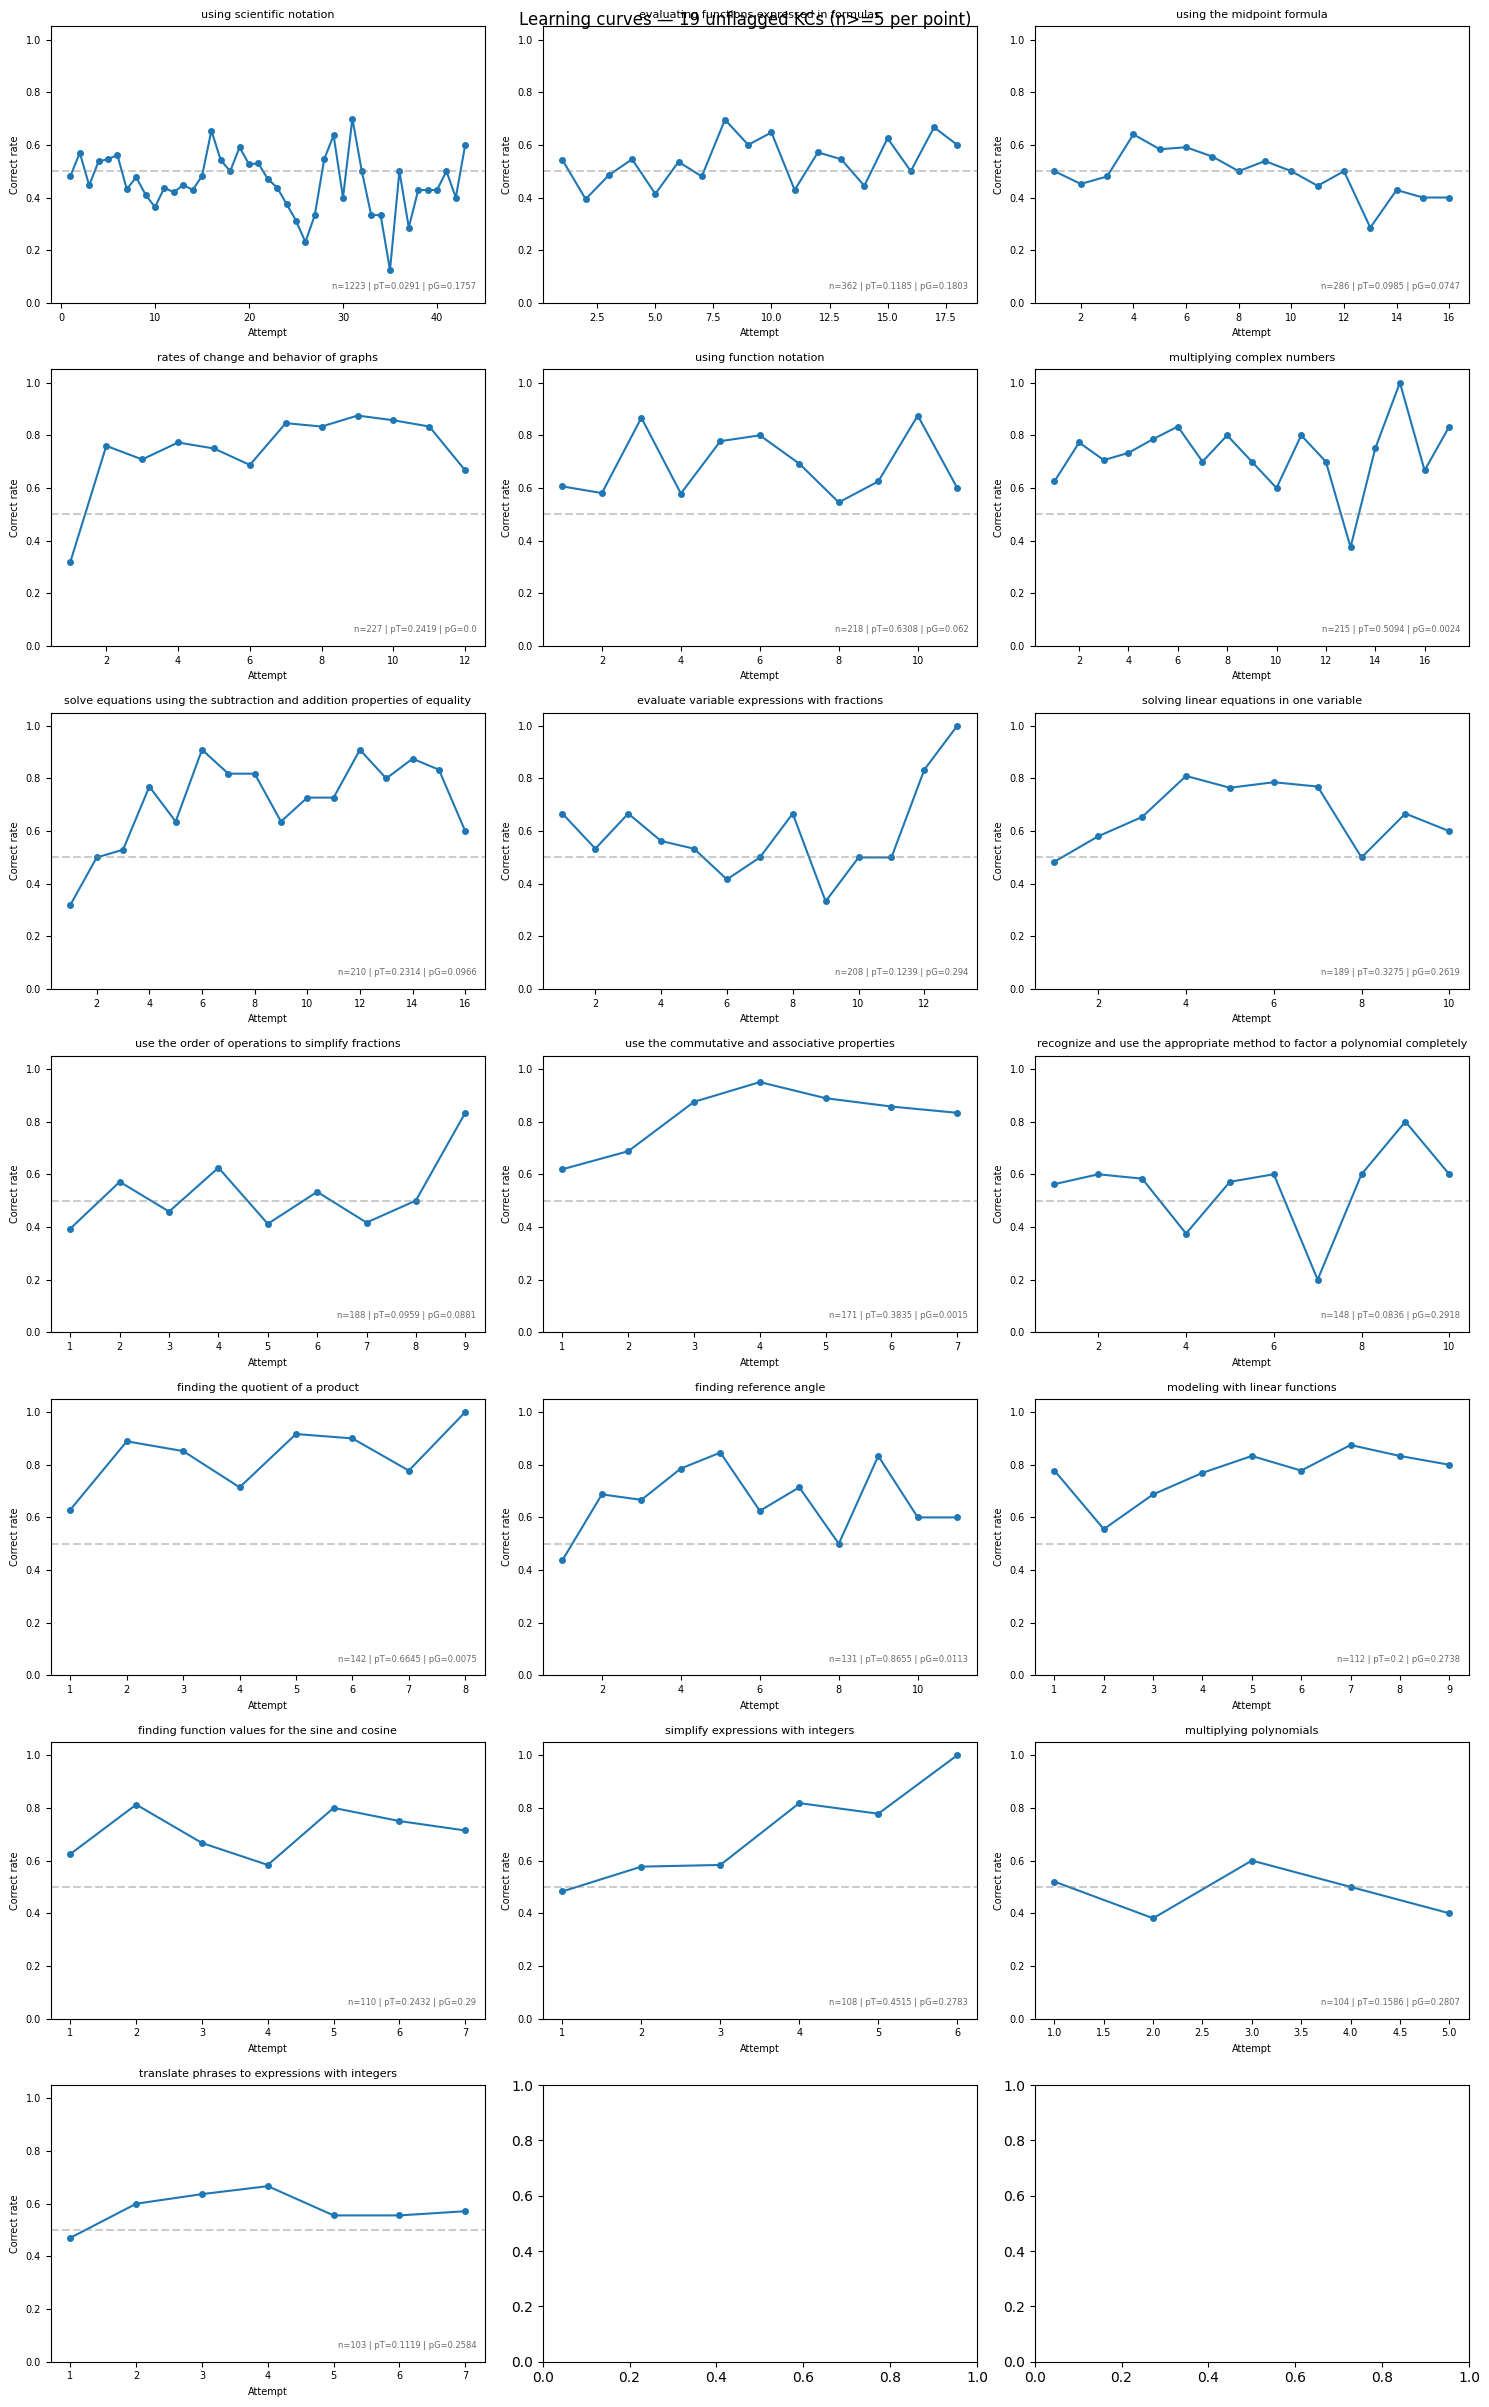

In [9]:
# ── Sequence plots for all 19 unflagged KCs ────────────────────────────────
# Each subplot: correct rate by attempt number (learning curve)

n = len(unflagged)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flat

for ax, kc in zip(axes, unflagged_df.index):
    sub = df[df['skill_name'] == kc].copy()
    sub['attempt'] = sub.groupby('user_id').cumcount() + 1
    stats = sub.groupby('attempt').agg(correct_rate=('correct','mean'), n=('correct','count')).reset_index()
    stats = stats[stats['n'] >= 5]

    ax.plot(stats['attempt'], stats['correct_rate'], marker='o', markersize=4)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.05)
    ax.set_title(kc.replace('_', ' '), fontsize=8, wrap=True)
    ax.set_xlabel('Attempt', fontsize=7)
    ax.set_ylabel('Correct rate', fontsize=7)
    ax.tick_params(labelsize=7)

    r = unflagged_df.loc[kc]
    ax.text(0.98, 0.05,
            f"n={r['responses']} | pT={r['probTransit']} | pG={r['probGuess']}",
            transform=ax.transAxes, fontsize=6, ha='right', color='dimgray')

# Hide unused subplots
for ax in list(axes)[n:]:
    ax.set_visible(False)

plt.suptitle('Learning curves — 19 unflagged KCs (n>=5 per point)', fontsize=12)
plt.tight_layout()
plt.show()

,probMastery_naive,probMastery_adj,probMastery_delta,probTransit_naive,probTransit_adj,probTransit_delta,probSlip_naive,probSlip_adj,probSlip_delta,probGuess_naive,probGuess_adj,probGuess_delta
kc,,,,,,,,,,,,
composition_of_functions,0.0053,0.8834,0.8781,0.0112,0.0000,-0.0112,0.2601,0.4726,0.2126,0.5530,0.1446,-0.4084
fitting_linear_models_to_data,0.9229,0.0601,-0.8628,0.0137,0.0219,0.0081,0.4606,0.1459,-0.3148,0.1402,0.2748,0.1346
the_discriminant,0.0414,0.8867,0.8453,0.0740,0.0000,-0.0740,0.3736,0.4963,0.1227,0.4909,0.0001,-0.4908
using_the_zero_exponent_rule_of_exponents,0.4398,0.9249,0.4851,0.2854,0.0022,-0.2832,0.0001,0.1094,0.1093,0.8012,0.0000,-0.8012
adding_and_subtracting_complex_numbers,0.5264,0.4282,-0.0982,0.1064,0.0407,-0.0656,0.4287,0.0103,-0.4184,0.9720,0.2202,-0.7518
expressing_square_roots_of_negative_numbers_as_multiples_of_i,0.9426,0.1936,-0.7490,0.3477,0.0040,-0.3437,0.2468,0.0005,-0.2463,0.0021,0.5161,0.5140
finding_reference_angle,0.5936,0.1874,-0.4062,0.8655,0.1288,-0.7367,0.2719,0.1723,-0.0995,0.0113,0.2919,0.2805
using_the_power_rule_of_exponents,0.2335,0.9629,0.7294,0.2020,0.0001,-0.2019,0.0031,0.2066,0.2035,0.7042,0.0000,-0.7042
evaluating_a_function_given_in_tabular_form,0.1406,0.6090,0.4685,0.3519,0.0738,-0.2781,0.2413,0.0824,-0.1588,1.0000,0.2797,-0.7203


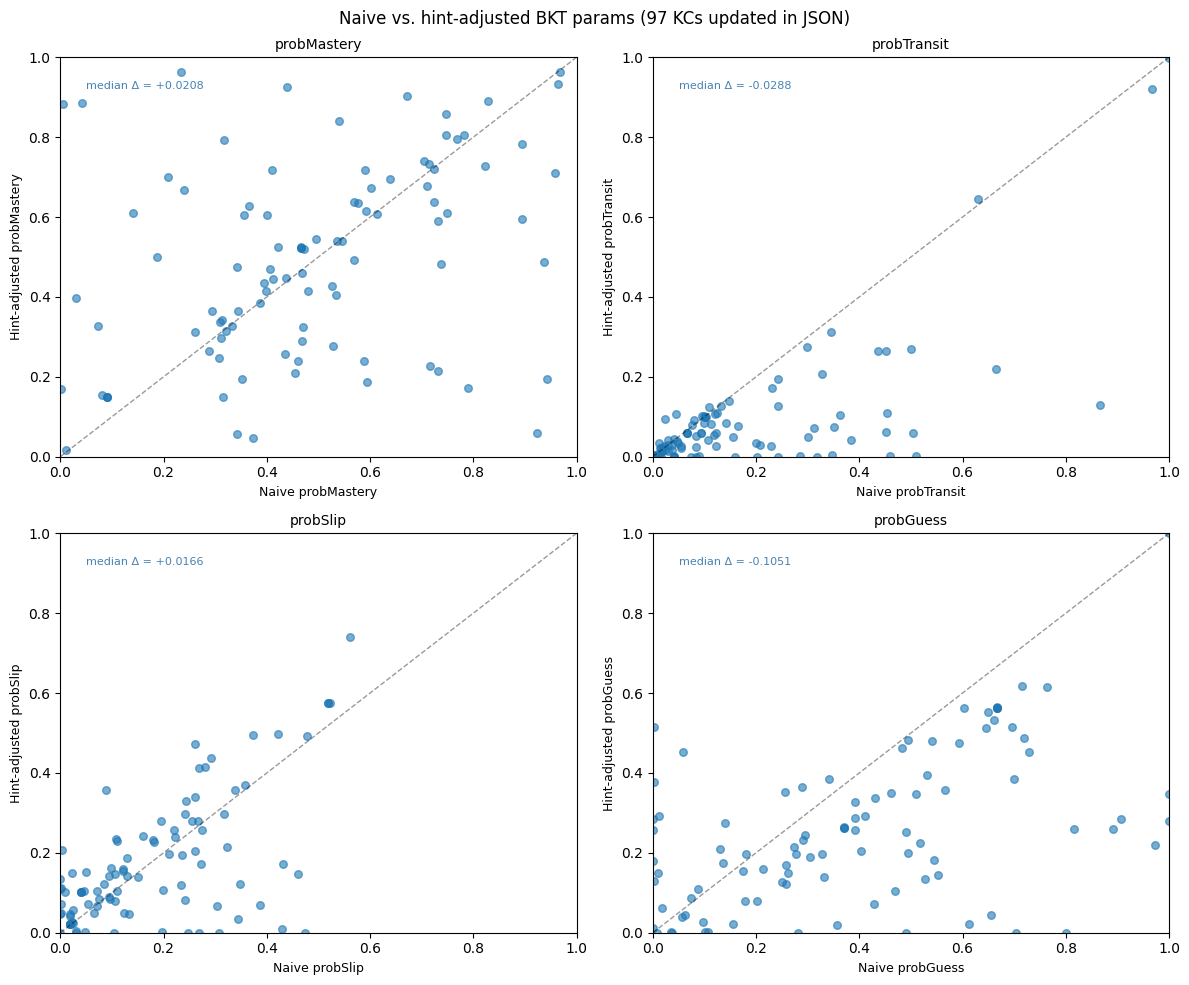

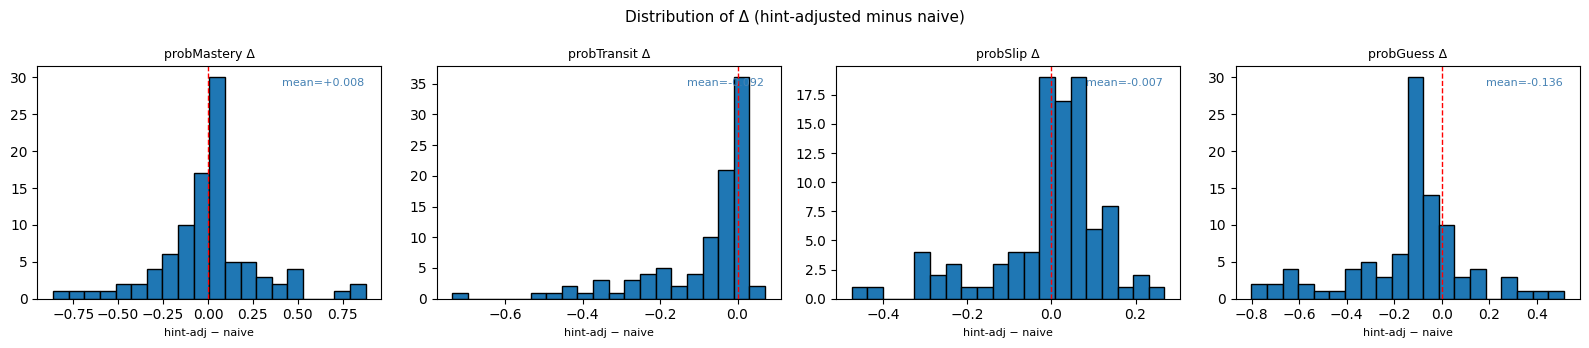

In [10]:
# ── Naive vs. hint-adjusted BKT params — 97 updated KCs ─────────────────

params_naive = pd.read_csv('data/fitted_params.csv', index_col=[0,1,2])
params_adj   = pd.read_csv('data/fitted_params_hint_adjusted.csv', index_col=[0,1,2])

flat_naive = params_naive['value'].unstack('param').droplevel('class')
flat_adj   = params_adj['value'].unstack('param').droplevel('class')

# Keep only the 97 KCs updated in JSON
kcs_updated = [kc for kc in flat_naive.index if kc in bkt_json]

pmap = {'prior': 'probMastery', 'learns': 'probTransit', 'slips': 'probSlip', 'guesses': 'probGuess'}

rows = []
for kc in kcs_updated:
    n = flat_naive.loc[kc]
    a = flat_adj.loc[kc] if kc in flat_adj.index else pd.Series(dtype=float)
    row = {'kc': kc}
    for col, label in pmap.items():
        row[f'{label}_naive']   = round(float(n[col]), 4) if col in n.index else float('nan')
        row[f'{label}_adj']     = round(float(a[col]), 4) if col in a.index else float('nan')
        row[f'{label}_delta']   = round(float(a[col]) - float(n[col]), 4) if col in a.index else float('nan')
    rows.append(row)

cmp = pd.DataFrame(rows).set_index('kc')

# ── Table: params that changed the most ──────────────────────────────────────
delta_cols = [c for c in cmp.columns if c.endswith('_delta')]
cmp['max_abs_delta'] = cmp[delta_cols].abs().max(axis=1)
display(cmp.sort_values('max_abs_delta', ascending=False).drop(columns='max_abs_delta').head(20))

# ── Scatter: naive vs hint-adjusted for each of the 4 params ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (col, label) in zip(axes.flat, pmap.items()):
    x = cmp[f'{label}_naive']
    y = cmp[f'{label}_adj']
    ax.scatter(x, y, alpha=0.6, s=30)
    lims = [0, 1]
    ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'Naive {label}', fontsize=9)
    ax.set_ylabel(f'Hint-adjusted {label}', fontsize=9)
    ax.set_title(label, fontsize=10)
    # median delta annotation
    med_delta = (y - x).median()
    ax.text(0.05, 0.92, f'median Δ = {med_delta:+.4f}', transform=ax.transAxes, fontsize=8, color='steelblue')

plt.suptitle('Naive vs. hint-adjusted BKT params (97 KCs updated in JSON)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Delta histograms ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (col, label) in zip(axes, pmap.items()):
    deltas = cmp[f'{label}_delta'].dropna()
    ax.hist(deltas, bins=20, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{label} Δ', fontsize=9)
    ax.set_xlabel('hint-adj − naive', fontsize=8)
    ax.text(0.95, 0.95, f'mean={deltas.mean():+.3f}', transform=ax.transAxes,
            fontsize=8, ha='right', va='top', color='steelblue')

plt.suptitle('Distribution of Δ (hint-adjusted minus naive)', fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
# ── Summary table: flags on hint-adjusted params (97 updated KCs) ──────────

params_adj = pd.read_csv('data/fitted_params_hint_adjusted.csv', index_col=[0,1,2])
flat_adj   = params_adj['value'].unstack('param').droplevel('class')

updated_kcs_adj = [kc for kc in flat_adj.index if kc in bkt_json]
print(f'Updated in JSON (hint-adjusted): {len(updated_kcs_adj)}')

rows_adj = []
for kc in updated_kcs_adj:
    row = flat_adj.loc[kc]
    sub = df[df['skill_name'] == kc]
    n_students = sub['user_id'].nunique()
    n_responses = len(sub)
    correct_rate = sub['correct'].mean()
    flags = []
    if row['slips'] > 0.3:    flags.append('high_slip')
    if row['guesses'] > 0.3:  flags.append('high_guess')
    if row['learns'] > 0.9:   flags.append('high_transit')
    if row['learns'] < 0.02:  flags.append('low_transit')
    if row['prior'] > 0.8:    flags.append('high_prior')
    rows_adj.append({
        'kc': kc,
        'n_students': n_students,
        'n_responses': n_responses,
        'correct_rate': round(correct_rate, 3),
        'probMastery':  round(row['prior'], 4),
        'probTransit':  round(row['learns'], 4),
        'probSlip':     round(row['slips'], 4),
        'probGuess':    round(row['guesses'], 4),
        'flags': ' '.join(flags),
    })

summary_adj = pd.DataFrame(rows_adj).set_index('kc').sort_values('flags')
n_flagged_adj = (summary_adj['flags'] != '').sum()
print(f'Flagged: {n_flagged_adj} / {len(summary_adj)}  |  Clean: {len(summary_adj) - n_flagged_adj}')
print()
flag_counts = summary_adj['flags'].str.split().explode().value_counts()
print('Flag breakdown:')
print(flag_counts.to_string())

pd.set_option('display.max_rows', 120)
pd.set_option('display.max_colwidth', 60)
display(summary_adj)


Updated in JSON (hint-adjusted): 97


Flagged: 59 / 97  |  Clean: 38

Flag breakdown:
flags
high_guess      32
low_transit     29
high_slip       16
high_prior      12
high_transit     2


,n_students,n_responses,correct_rate,probMastery,probTransit,probSlip,probGuess,flags
kc,,,,,,,,
writing_the_equation_of_lines_parallel_or_perpendicular_to_a_given_line,29,157,0.631,0.3981,0.0758,0.2344,0.2253,
find_factors,201,3646,0.777,0.1485,0.0587,0.1019,0.2637,
find_prime_factorizations_and_least_common_multiples,200,1112,0.567,0.3128,0.0600,0.1426,0.1901,
finding_a_linear_equation,27,288,0.681,0.6151,0.0258,0.1596,0.2041,
finding_reference_angle,16,131,0.687,0.1874,0.1288,0.1723,0.2919,
finding_the_power_of_a_product,29,151,0.781,0.7414,0.1263,0.1214,0.1054,
finding_the_quotient_of_a_product,27,142,0.817,0.6781,0.2198,0.1036,0.0001,
finding_x_intercepts_and_y_intercepts,66,825,0.484,0.2573,0.0235,0.2135,0.1758,
linear_functions,32,523,0.467,0.2279,0.0356,0.0689,0.2105,


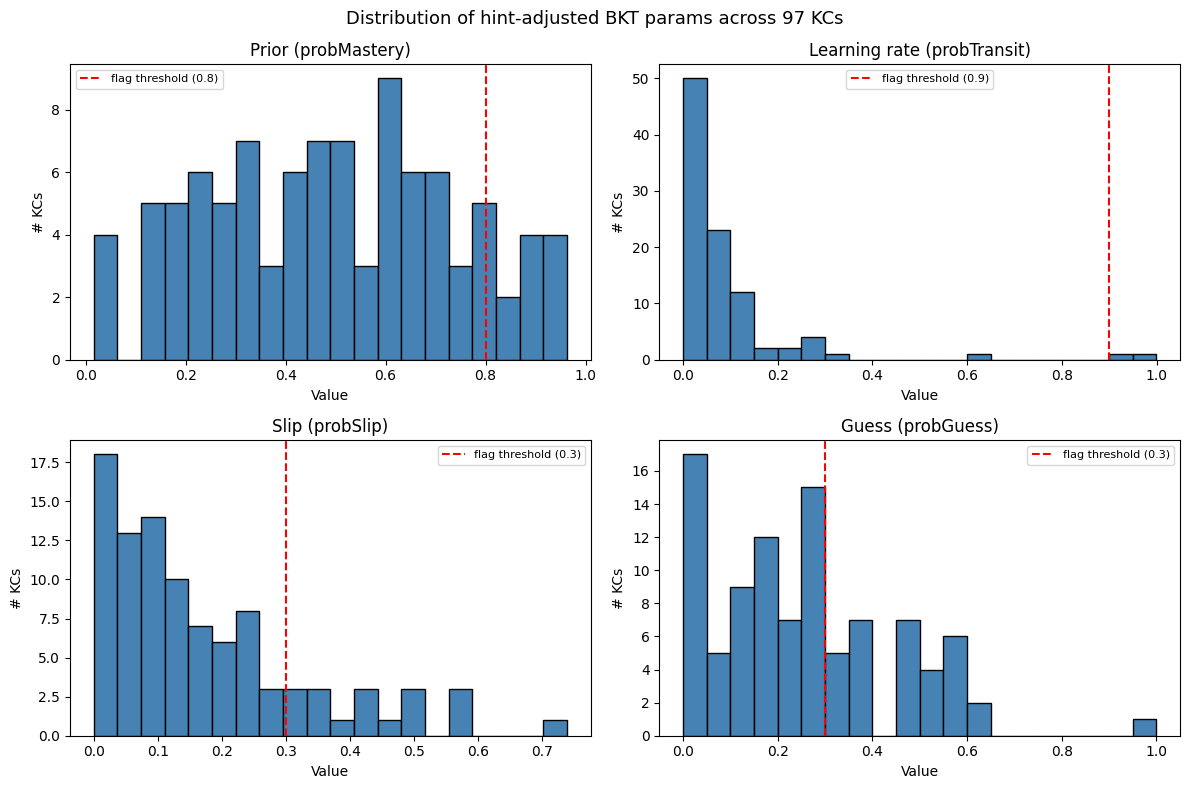

In [12]:
# ── Param distributions: hint-adjusted 97 KCs ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
param_cols = ['probMastery', 'probTransit', 'probSlip', 'probGuess']
titles = ['Prior (probMastery)', 'Learning rate (probTransit)', 'Slip (probSlip)', 'Guess (probGuess)']
thresholds = [0.8, 0.9, 0.3, 0.3]

for ax, col, title, thresh in zip(axes.flat, param_cols, titles, thresholds):
    ax.hist(summary_adj[col], bins=20, edgecolor='black', color='steelblue')
    ax.axvline(thresh, color='red', linestyle='--', label=f'flag threshold ({thresh})')
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('# KCs')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of hint-adjusted BKT params across 97 KCs', fontsize=13)
plt.tight_layout()
plt.show()


In [13]:
# ── Unflagged KCs: hint-adjusted fit ────────────────────────────────────────

unflagged_adj = [
    kc for kc in flat_adj.index
    if kc in bkt_json
    and not (flat_adj.loc[kc, 'slips']   > 0.3
          or flat_adj.loc[kc, 'guesses'] > 0.3
          or flat_adj.loc[kc, 'learns']  > 0.9
          or flat_adj.loc[kc, 'learns']  < 0.02
          or flat_adj.loc[kc, 'prior']   > 0.8)
]
print(f'Unflagged KCs (hint-adjusted): {len(unflagged_adj)}\n')

rows_uf = []
for kc in unflagged_adj:
    sub_raw = df_raw[df_raw['eventType'] == 'answerStep'].copy()
    sub_raw = sub_raw[sub_raw['knowledgeComponents'].notna()]
    sub_raw['knowledgeComponents'] = sub_raw['knowledgeComponents'].apply(ast.literal_eval)
    sub_raw = sub_raw.explode('knowledgeComponents')
    sub_raw = sub_raw[sub_raw['knowledgeComponents'] == kc].copy()
    sub_raw = sub_raw.rename(columns={'oats_user_id': 'user_id', 'isCorrect': 'correct'})
    sub_raw['correct'] = sub_raw['correct'].astype(int)
    sub_raw = sub_raw.sort_values('time_stamp')

    seqs = sub_raw.groupby('user_id')['correct'].apply(list)
    seq_lengths = seqs.apply(len)
    courses = sorted(sub_raw['course_name'].dropna().unique())

    r = flat_adj.loc[kc]
    rows_uf.append({
        'kc': kc,
        'responses': len(sub_raw),
        'students': sub_raw['user_id'].nunique(),
        'correct_rate': round(sub_raw['correct'].mean(), 3),
        'median_seq_len': seq_lengths.median(),
        'pct_lte3': round((seq_lengths <= 3).mean(), 2),
        'probMastery': round(r['prior'], 4),
        'probTransit': round(r['learns'], 4),
        'probSlip':    round(r['slips'], 4),
        'probGuess':   round(r['guesses'], 4),
        'courses': ', '.join(c.split(' ')[0] for c in courses) if courses else 'unknown',
    })

unflagged_adj_df = pd.DataFrame(rows_uf).set_index('kc').sort_values('responses', ascending=False)
pd.set_option('display.max_colwidth', 80)
display(unflagged_adj_df)


Unflagged KCs (hint-adjusted): 38



,responses,students,correct_rate,median_seq_len,pct_lte3,probMastery,probTransit,probSlip,probGuess,courses
kc,,,,,,,,,,
find_factors,3646,201,0.777,5.0,0.43,0.1485,0.0587,0.1019,0.2637,"AIED, FA25:, FA25:, MAT-000C-33611, SP26:, SP26:, SP26:, SP26:, SP26:"
and_least_common_multiples,3646,201,0.777,5.0,0.43,0.1488,0.0589,0.1021,0.2629,"AIED, FA25:, FA25:, MAT-000C-33611, SP26:, SP26:, SP26:, SP26:, SP26:"
prime_factorizations,3646,201,0.777,5.0,0.43,0.1489,0.0590,0.1022,0.2626,"AIED, FA25:, FA25:, MAT-000C-33611, SP26:, SP26:, SP26:, SP26:, SP26:"
find_prime_factorizations_and_least_common_multiples,1112,200,0.567,3.0,0.51,0.3128,0.0600,0.1426,0.1901,"SP26:, SP26:, SP26:, Temp, Tutoria"
performing_calculations_using_the_order_of_operations,1084,144,0.716,4.0,0.44,0.6083,0.0593,0.1552,0.1972,"CONTROL, Digital, MAT-001-31365, MAT-001-33621, MAT-001-71668, MAT-001-72135..."
finding_x_intercepts_and_y_intercepts,825,66,0.484,6.5,0.38,0.2573,0.0235,0.2135,0.1758,"MAT-001-71668, MAT-001-72135, MAT-001-72192"
linear_functions,523,32,0.467,9.5,0.25,0.2279,0.0356,0.0689,0.2105,"MAT-001-71668, MAT-001-72135, MAT-001-72192, MAT-003-31748, MAT-003-31749, M..."
evaluating_functions_expressed_in_formulas,362,35,0.525,9.0,0.06,0.0571,0.0554,0.1065,0.1983,"MAT-003-31749, MAT-003-78818, MAT-003-78819"
translate_an_english_phrase_to_an_algebraic_expression,343,52,0.679,4.0,0.21,0.5439,0.1080,0.1034,0.1395,"FA25:, FA25:, MAT-000C-33611, SP26:, SP26:"


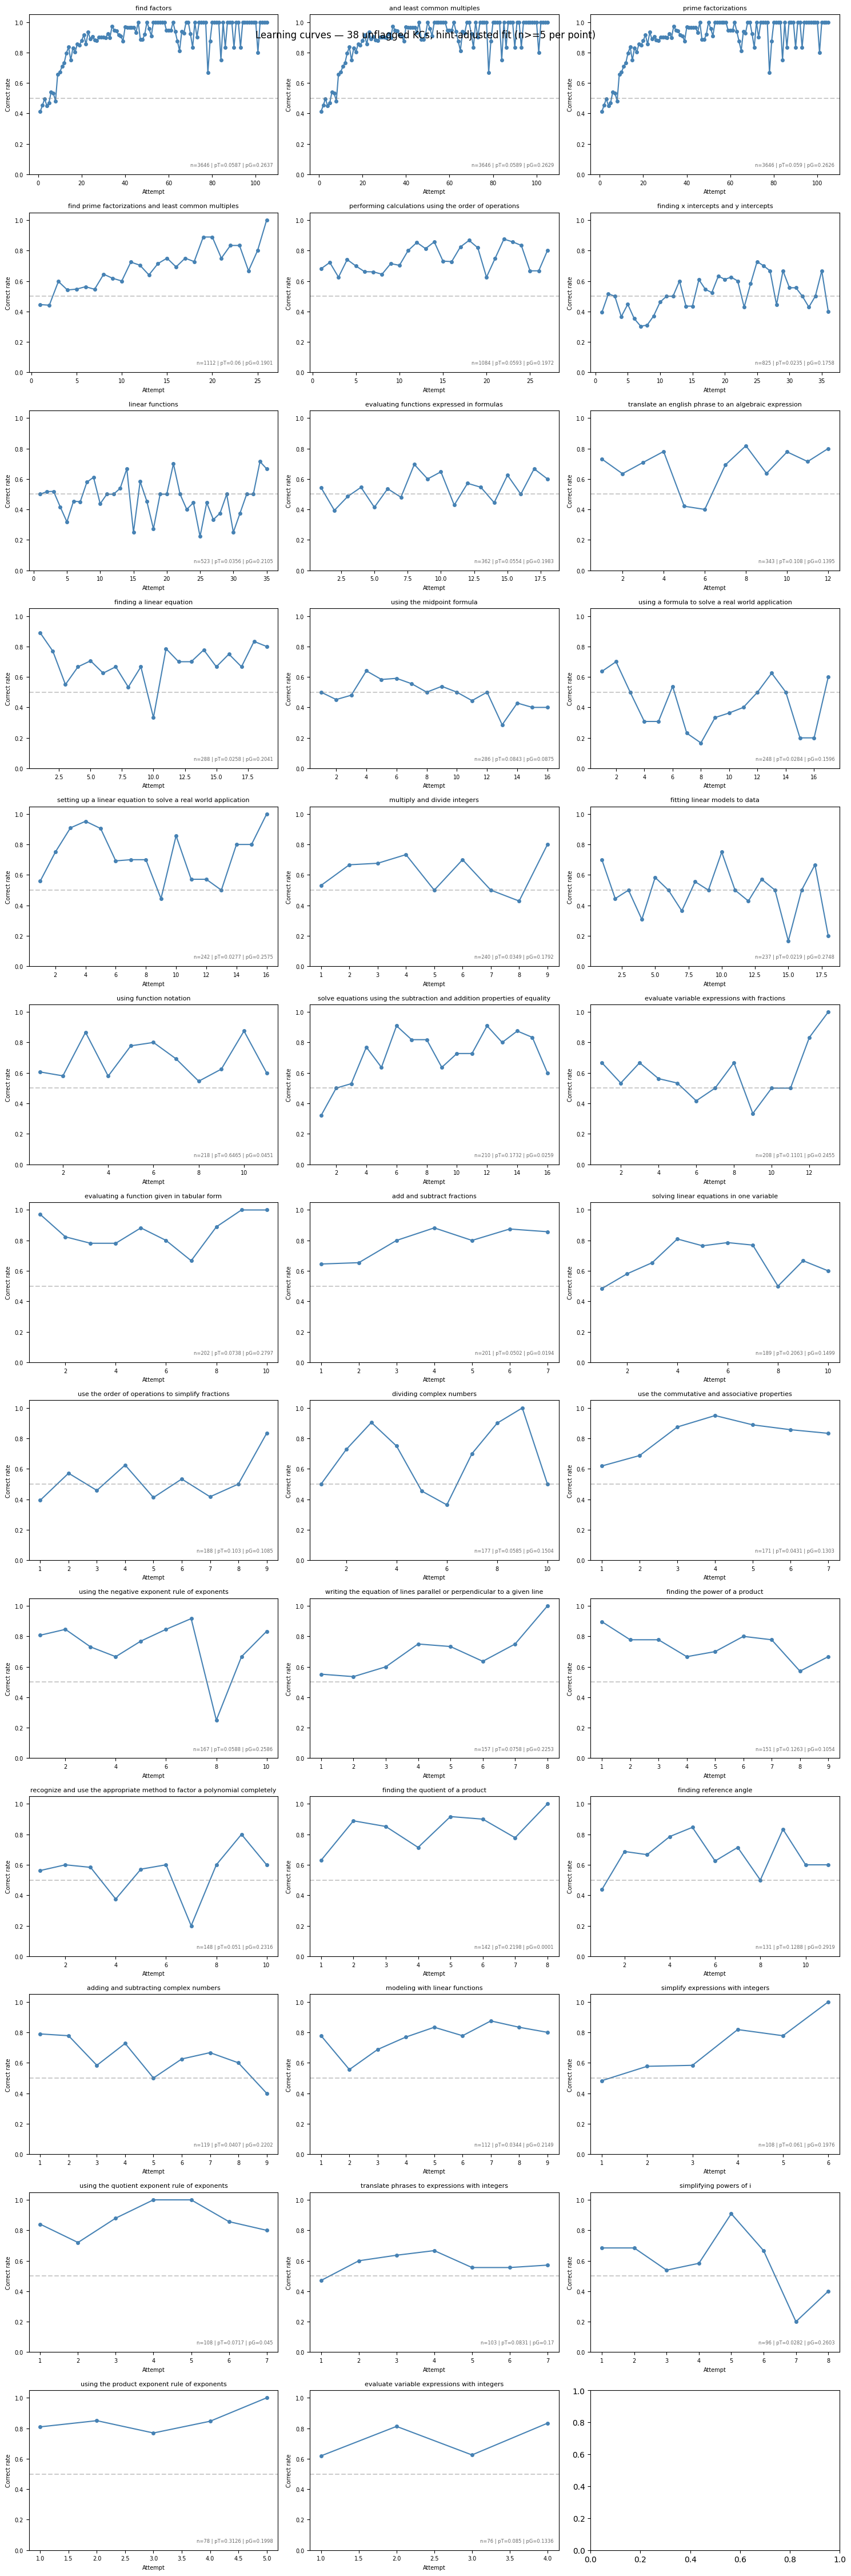

In [14]:
# ── Learning curves: unflagged hint-adjusted KCs ────────────────────────────
n = len(unflagged_adj_df)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flat if n > 1 else [axes]

for ax, kc in zip(axes, unflagged_adj_df.index):
    sub = df[df['skill_name'] == kc].copy()
    sub['attempt'] = sub.groupby('user_id').cumcount() + 1
    stats = sub.groupby('attempt').agg(correct_rate=('correct','mean'), n=('correct','count')).reset_index()
    stats = stats[stats['n'] >= 5]

    ax.plot(stats['attempt'], stats['correct_rate'], marker='o', markersize=4, color='steelblue')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.05)
    ax.set_title(kc.replace('_', ' '), fontsize=8, wrap=True)
    ax.set_xlabel('Attempt', fontsize=7)
    ax.set_ylabel('Correct rate', fontsize=7)
    ax.tick_params(labelsize=7)

    r = unflagged_adj_df.loc[kc]
    ax.text(0.98, 0.05,
            f"n={r['responses']} | pT={r['probTransit']} | pG={r['probGuess']}",
            transform=ax.transAxes, fontsize=6, ha='right', color='dimgray')

for ax in list(axes)[n:]:
    ax.set_visible(False)

plt.suptitle(f'Learning curves — {n} unflagged KCs, hint-adjusted fit (n>=5 per point)', fontsize=12)
plt.tight_layout()
plt.show()
